# Eye State Classifier Training

**Objective:** Train a Convolutional Neural Network (CNN) on the MRL Eye Dataset to classify eye images as open (1) or closed (0). All images are resized to 24x24 pixels as per project requirements.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models

# Define paths and parameters
train_dir = '../data/train'
test_dir = '../data/test'
IMG_SIZE = (24, 24) 
BATCH_SIZE = 32

## 1. Data Loading and Preprocessing
Load the images from the `train` and `test` directories. Because standard alphabetical ordering places `close` before `open`, TensorFlow will automatically assign `close = 0` and `open = 1`. 

A rescaling layer is also mapped to the dataset to normalize pixel values between 0 and 1.

In [4]:
# Load datasets from directories
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale' 
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

# Normalize pixel values
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

Found 81675 files belonging to 2 classes.
Found 3223 files belonging to 2 classes.


## 2. Model Architecture
Build a simple CNN using Keras. The network consists of convolutional layers for feature extraction, max-pooling layers for downsampling, and a dense output layer with a sigmoid activation function for binary classification. A dropout layer is included to help prevent overfitting.

In [5]:
# Build the CNN
model = models.Sequential([
    layers.Input(shape=(24, 24, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(1, activation='sigmoid') 
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,481 (330.00 KB)

 Trainable params: 84,481 (330.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Model Training
Train the compiled model over 10 epochs. 

In [6]:
EPOCHS = 10

# Train the model and store the history
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9334 - loss: 0.1777 - val_accuracy: 0.9528 - val_loss: 0.1344
Epoch 2/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9708 - loss: 0.0842 - val_accuracy: 0.9296 - val_loss: 0.2047
Epoch 3/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9760 - loss: 0.0679 - val_accuracy: 0.9417 - val_loss: 0.1843
Epoch 4/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9789 - loss: 0.0595 - val_accuracy: 0.9566 - val_loss: 0.1327
Epoch 5/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9807 - loss: 0.0540 - val_accuracy: 0.9401 - val_loss: 0.1849
Epoch 6/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9820 - loss: 0.0507 - val_accuracy: 0.9466 - val_loss: 0.1864
Epoch 7/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9831 - loss: 0.0476 - val_accuracy: 0.9342 - val_loss: 0.2041
Epoch 8/10
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9839 - loss

## 4. Exporting the Model
Save the trained model into the standard SavedModel format so it can be subsequently converted into a TFLite file for Flutter integration.

In [8]:
# Save the model
saved_model_path = '../models'
model.export(saved_model_path)
print(f"Model successfully saved to {saved_model_path}/")

INFO:tensorflow:Assets written to: ../models\assets


INFO:tensorflow:Assets written to: ../models\assets


Saved artifact at '../models'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 24, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2625685519056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2625685518864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2625715683984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2625715684752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2625715685136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2625715683792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2625715684560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2625715685712: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model successfully saved to ../models/


## 5. Evaluation Metrics
This section evaluates the overall performance of the eye state classifier. It extracts the final training and validation accuracies achieved during the last epoch and generates a confusion matrix against the test dataset to visualize correct classifications versus misclassifications.

--- MODEL ACCURACY ---
Final Training Accuracy: 98.60%
Final Validation Accuracy: 94.32%
----------------------

Generating predictions on the test dataset for the confusion matrix...


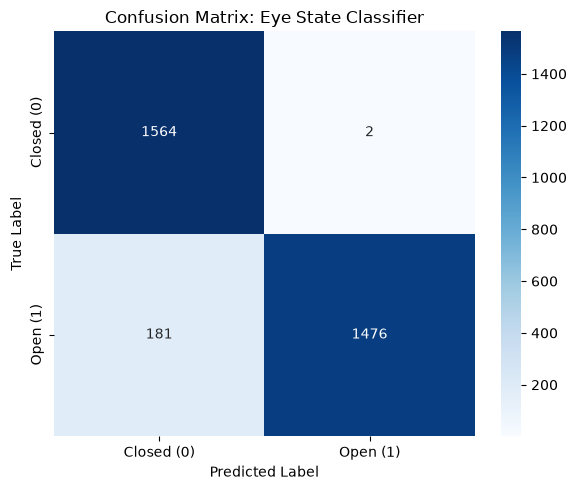

In [14]:
# Print Final Accuracy Metrics
# Extracting the final values from the 'history' object created during training
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print("--- MODEL ACCURACY ---")
print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")
print("-" * 22 + "\n")

# Extract true labels and generate predictions from the test dataset
y_true = []
y_pred_probs = []

print("Generating predictions on the test dataset for the confusion matrix...")
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    # Predict probabilities for the current batch
    predictions = model.predict(images, verbose=0)
    y_pred_probs.extend(predictions.flatten())

# Convert probabilities to binary class labels (0.5 threshold)
y_pred = [1 if p >= 0.5 else 0 for p in y_pred_probs]

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Closed (0)', 'Open (1)'], 
            yticklabels=['Closed (0)', 'Open (1)'])

plt.title('Confusion Matrix: Eye State Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 6. Convert to TFLite
Convert the exported TensorFlow SavedModel into a lightweight `.tflite` format required by Flutter. This final file (`eye_classifier.tflite`) will be transferred into the mobile app's `assets/` folder.

In [9]:
saved_model_path = '../models'

# Initialize the converter
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)

# Perform the conversion
tflite_model = converter.convert()

# Save the converted model to the local directory
model_filename = 'eye_classifier.tflite'
with open(model_filename, 'wb') as f:
    f.write(tflite_model)

print(f"Success! Model exported as {model_filename}")

Success! Model exported as eye_classifier.tflite
